# Model Sentimen Ulasan

Notebook ini melatih model yang menebak apakah sebuah ulasan bernada positif atau negatif, memakai data dari `05_data_prep_ulasan.ipynb`.

Tantangan utamanya adalah ketidakseimbangan kelas: hanya 2,4% ulasan yang negatif. Karena itu model dinilai terutama dari kemampuannya mengenali ulasan negatif, bukan dari akurasi keseluruhan.

Urutan langkah:

1. Membagi data menjadi data latih dan data uji
2. Membuat model patokan (baseline)
3. Model pertama: TF-IDF dan Logistic Regression
4. Menangani ketidakseimbangan kelas
5. Mencari pengaturan terbaik dengan GridSearchCV
6. Menggeser ambang keputusan
7. Evaluasi akhir di data uji
8. Kata yang paling berpengaruh
9. Analisis kesalahan
10. Menyimpan model

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    TunedThresholdClassifierCV,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline

In [2]:
# Gaya grafik, sama dengan notebook sebelumnya
BIRU = "#2a78d6"
ORANYE = "#eb6834"
ABU = "#c8c6bf"
TEKS = "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8983",
    "axes.labelcolor": TEKS,
    "xtick.color": TEKS,
    "ytick.color": TEKS,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
})

In [3]:
df = pd.read_csv("../Dataset/processed/ulasan_bersih.csv")
print(df.shape)
df["label"].value_counts()

(38585, 9)


label
positif    37663
negatif      922
Name: count, dtype: int64

## 1. Bagi data menjadi data latih dan data uji

Data dibagi dua:

- Data latih (80%): dipakai untuk melatih model dan memilih pengaturan terbaik.
- Data uji (20%): disimpan dan baru dipakai sekali di akhir, untuk mengukur seberapa baik model bekerja pada ulasan yang belum pernah dilihatnya.

`stratify=y` memastikan porsi ulasan negatif di data latih dan data uji sama, yaitu sekitar 2,4%. Tanpa ini, bisa saja data uji kebetulan hanya berisi sedikit sekali ulasan negatif. `random_state=42` membuat pembagiannya selalu sama setiap kali notebook dijalankan.

### Kenapa persiapan data untuk model dilakukan setelah split?

Di notebook 05, teks sudah dibersihkan sebelum data dibagi. Itu aman karena setiap ulasan dibersihkan sendiri-sendiri dengan aturan tetap. Ulasan lain tidak memengaruhi hasilnya.

TF-IDF berbeda. TF-IDF "belajar" dari data: kosakatanya dan bobot setiap kata dihitung dari seluruh ulasan yang diberikan kepadanya. Kalau TF-IDF dilatih dengan seluruh data sebelum dibagi, informasi dari data uji ikut bocor ke model. Akibatnya skor data uji terlihat lebih bagus dari kemampuan model yang sebenarnya. Kebocoran seperti ini disebut data leakage.

Cara mencegahnya adalah menggabungkan TF-IDF dan model dalam satu `Pipeline`. Dengan pipeline, TF-IDF selalu dilatih hanya dengan data latih, termasuk di dalam setiap lipatan cross-validation.

In [4]:
X = df["teks_bersih"]
y = df["label"]

X_latih, X_uji, y_latih, y_uji = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Data latih:", len(X_latih), "| negatif:", (y_latih == "negatif").sum())
print("Data uji  :", len(X_uji), "| negatif:", (y_uji == "negatif").sum())

Data latih: 30868 | negatif: 738
Data uji  : 7717 | negatif: 184


## 2. Model patokan (baseline)

Model patokan adalah model paling sederhana yang bisa dibuat. Di sini modelnya selalu menebak label yang paling sering muncul, yaitu "positif". Model apa pun yang dibuat setelah ini harus lebih baik dari patokan ini.

In [5]:
patokan = DummyClassifier(strategy="most_frequent").fit(X_latih, y_latih)
print(classification_report(y_uji, patokan.predict(X_uji), digits=3, zero_division=0))

              precision    recall  f1-score   support

     negatif      0.000     0.000     0.000       184
     positif      0.976     1.000     0.988      7533

    accuracy                          0.976      7717
   macro avg      0.488     0.500     0.494      7717
weighted avg      0.953     0.976     0.964      7717



Model patokan mendapat akurasi 97,6% tanpa belajar apa pun, tetapi tidak menemukan satu pun ulasan negatif. Inilah alasan akurasi tidak bisa dipakai sebagai ukuran utama.

Tiga ukuran yang dipakai di notebook ini, semuanya untuk kelas negatif:

- Precision: dari semua ulasan yang ditebak negatif, berapa persen yang benar-benar negatif. Precision rendah berarti banyak alarm palsu.
- Recall: dari semua ulasan yang benar-benar negatif, berapa persen yang berhasil ditemukan. Recall rendah berarti banyak keluhan yang terlewat.
- F1: gabungan precision dan recall (rata-rata harmonik). Nilainya hanya tinggi kalau keduanya tinggi. F1 dipakai sebagai ukuran utama untuk memilih model.

## 3. Model pertama: TF-IDF dan Logistic Regression

Model butuh angka, bukan teks. TF-IDF mengubah setiap ulasan menjadi deretan angka, satu angka untuk setiap kata di kosakata:

- TF (term frequency): seberapa sering kata muncul di ulasan itu.
- IDF (inverse document frequency): kata yang muncul di hampir semua ulasan, seperti "barang", diberi bobot kecil. Kata yang jarang dan spesifik, seperti "retur", diberi bobot besar.

Pengaturan yang dipakai:

- `ngram_range=(1, 2)`: selain kata tunggal, pasangan dua kata juga dihitung. Jadi "tidak sesuai" dikenali sebagai satu kesatuan, bukan hanya "tidak" dan "sesuai" secara terpisah.
- `min_df=2`: kata yang hanya muncul di satu ulasan diabaikan, karena biasanya salah ketik.
- `sublinear_tf=True`: kata yang diulang berkali-kali di satu ulasan tidak diberi bobot berlebihan.

Logistic Regression lalu mempelajari bobot untuk setiap kata. Kata dengan bobot negatif mendorong tebakan ke arah "negatif", dan sebaliknya. Model ini sederhana, cepat, dan bobotnya mudah dibaca, sehingga cocok sebagai model pertama.

`n_jobs=2` di kode berarti proses dijalankan paralel di 2 core CPU. Angka ini sengaja dibatasi. Dengan `n_jobs=-1` (semua core), setiap proses memuat salinan data sendiri, sehingga pemakaian RAM berlipat dan laptop bisa kehabisan memori.

Model dinilai dengan cross-validation 5 lipatan di data latih. Data latih dibagi menjadi 5 bagian. Model dilatih 5 kali, dan setiap kali satu bagian yang berbeda dipakai untuk menilai. Skor akhirnya adalah rata-rata kelima penilaian itu. Cara ini lebih stabil daripada satu kali penilaian, dan data uji tetap tidak tersentuh.

In [6]:
f1_negatif = make_scorer(f1_score, pos_label="negatif")
ukuran = {
    "precision": make_scorer(precision_score, pos_label="negatif", zero_division=0),
    "recall": make_scorer(recall_score, pos_label="negatif"),
    "f1": f1_negatif,
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def buat_pipeline(**pengaturan_model):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("model", LogisticRegression(max_iter=3000, **pengaturan_model)),
    ])


def nilai_cv(model):
    hasil = cross_validate(model, X_latih, y_latih, cv=cv, scoring=ukuran, n_jobs=2)
    return {k: hasil[f"test_{k}"].mean() for k in ukuran}


perbandingan = {}
perbandingan["Logistic Regression standar"] = nilai_cv(buat_pipeline())
pd.DataFrame(perbandingan).T.round(3)

,precision,recall,f1
Logistic Regression standar,0.853,0.217,0.343


Precision-nya tinggi, tetapi recall-nya hanya sekitar 22%. Model jarang salah ketika menebak negatif, tetapi hampir 4 dari 5 ulasan negatif terlewat. Penyebabnya, model hanya melihat sedikit contoh negatif, sehingga lebih "aman" baginya untuk hampir selalu menebak positif.

## 4. Menangani ketidakseimbangan kelas

`class_weight="balanced"` membuat kesalahan pada ulasan negatif dihitung jauh lebih berat saat model belajar, sebanding dengan kelangkaannya. Di data ini, satu ulasan negatif bobotnya sekitar 40 kali lipat ulasan positif. Hasilnya, model lebih berani menebak negatif.

Cara lain yang sering dipakai adalah oversampling, yaitu memperbanyak contoh negatif dengan menyalinnya atau membuat contoh buatan (misalnya SMOTE). Untuk Logistic Regression, `class_weight` memberi efek yang mirip tanpa perlu mengubah data, jadi cara itu yang dipakai di sini.

In [7]:
perbandingan["Dengan class_weight balanced"] = nilai_cv(buat_pipeline(class_weight="balanced"))
pd.DataFrame(perbandingan).T.round(3)

,precision,recall,f1
Logistic Regression standar,0.853,0.217,0.343
Dengan class_weight balanced,0.364,0.809,0.502


Recall naik tajam menjadi sekitar 81%, tetapi precision turun menjadi sekitar 36%. Model sekarang menemukan sebagian besar ulasan negatif, tetapi juga sering salah menandai ulasan positif sebagai negatif. Precision dan recall hampir selalu tarik-menarik seperti ini. F1 tetap naik, dari sekitar 0,34 menjadi 0,50.

## 5. Mencari pengaturan terbaik dengan GridSearchCV

Logistic Regression punya pengaturan `C`, yang mengatur seberapa bebas model mengikuti data latih:

- `C` kecil: model dibatasi lebih ketat (regularisasi kuat). Model lebih sederhana, tetapi bisa terlalu kaku.
- `C` besar: model lebih bebas memberi bobot besar pada kata-kata tertentu. Model lebih detail, tetapi berisiko menghafal data latih (overfitting).

GridSearchCV mencoba setiap kombinasi `C` dan `class_weight`, menilai masing-masing dengan cross-validation, lalu memilih kombinasi dengan F1 tertinggi.

In [8]:
grid = GridSearchCV(
    buat_pipeline(),
    param_grid={
        "model__C": [0.3, 1, 3, 10, 30],
        "model__class_weight": [None, "balanced"],
    },
    scoring=f1_negatif,
    cv=cv,
    n_jobs=2,
)
grid.fit(X_latih, y_latih)

hasil_grid = pd.DataFrame(grid.cv_results_)[["param_model__C", "param_model__class_weight", "mean_test_score"]]
hasil_grid = hasil_grid.rename(columns={
    "param_model__C": "C",
    "param_model__class_weight": "class_weight",
    "mean_test_score": "f1_cv",
})
hasil_grid["class_weight"] = hasil_grid["class_weight"].fillna("tidak ada")
print("Pengaturan terbaik:", grid.best_params_)
hasil_grid.sort_values("f1_cv", ascending=False).round(3)

Pengaturan terbaik: {'model__C': 30, 'model__class_weight': None}


,C,class_weight,f1_cv
8,30.0,tidak ada,0.581
7,10.0,balanced,0.567
6,10.0,tidak ada,0.547
5,3.0,balanced,0.546
9,30.0,balanced,0.546
3,1.0,balanced,0.502
4,3.0,tidak ada,0.471
1,0.3,balanced,0.433
2,1.0,tidak ada,0.343
0,0.3,tidak ada,0.070


In [9]:
C_terbaik = grid.best_params_["model__C"]
cw_terbaik = grid.best_params_["model__class_weight"]
perbandingan["GridSearchCV"] = nilai_cv(buat_pipeline(C=C_terbaik, class_weight=cw_terbaik))
pd.DataFrame(perbandingan).T.round(3)

,precision,recall,f1
Logistic Regression standar,0.853,0.217,0.343
Dengan class_weight balanced,0.364,0.809,0.502
GridSearchCV,0.791,0.463,0.581


Pengaturan terbaik adalah `C=30` tanpa `class_weight`, dengan F1 sekitar 0,58. Model dengan `C` besar lebih berani memakai kata-kata yang spesifik, sehingga recall-nya naik tanpa mengorbankan precision sebanyak `class_weight`.

## 6. Menggeser ambang keputusan

Logistic Regression sebenarnya menghasilkan peluang, misalnya "peluang ulasan ini negatif = 0,3". Secara bawaan, ulasan ditebak negatif kalau peluangnya minimal 0,5. Angka 0,5 ini disebut ambang (threshold), dan tidak harus 0,5.

Untuk kelas yang langka, peluang negatif yang dihasilkan model jarang mencapai 0,5 walaupun ulasannya memang negatif. Menurunkan ambang membuat model lebih mudah menebak negatif (recall naik, precision turun). Menaikkan ambang berlaku sebaliknya.

`TunedThresholdClassifierCV` mencari ambang yang menghasilkan F1 tertinggi. Pencariannya juga memakai cross-validation di data latih, jadi data uji tetap tidak tersentuh. Ambang yang ditemukan tersimpan di dalam model, sehingga dashboard nanti otomatis memakai ambang yang sama.

In [10]:
model_akhir = TunedThresholdClassifierCV(
    buat_pipeline(C=C_terbaik, class_weight=cw_terbaik),
    scoring=f1_negatif,
    cv=cv,
    n_jobs=2,
)
model_akhir.fit(X_latih, y_latih)

print(f"Ambang terbaik: {model_akhir.best_threshold_:.3f}")
print(f"F1 cross-validation dengan ambang ini: {model_akhir.best_score_:.3f}")

Ambang terbaik: 0.232
F1 cross-validation dengan ambang ini: 0.626


Untuk membandingkan dengan langkah sebelumnya, precision dan recall pada ambang ini dihitung dari prediksi cross-validation di data latih. Setiap ulasan di data latih diberi peluang negatif oleh model yang tidak melihat ulasan itu saat dilatih, lalu ambang yang sudah ditemukan diterapkan.

In [11]:
peluang_cv = cross_val_predict(
    buat_pipeline(C=C_terbaik, class_weight=cw_terbaik),
    X_latih, y_latih, cv=cv, method="predict_proba", n_jobs=2,
)
kolom_negatif = list(model_akhir.classes_).index("negatif")
tebakan_cv = np.where(peluang_cv[:, kolom_negatif] >= model_akhir.best_threshold_, "negatif", "positif")

perbandingan["Ambang disesuaikan"] = {
    "precision": precision_score(y_latih, tebakan_cv, pos_label="negatif"),
    "recall": recall_score(y_latih, tebakan_cv, pos_label="negatif"),
    "f1": f1_score(y_latih, tebakan_cv, pos_label="negatif"),
}
tabel = pd.DataFrame(perbandingan).T
tabel.round(3)

,precision,recall,f1
Logistic Regression standar,0.853,0.217,0.343
Dengan class_weight balanced,0.364,0.809,0.502
GridSearchCV,0.791,0.463,0.581
Ambang disesuaikan,0.643,0.610,0.626


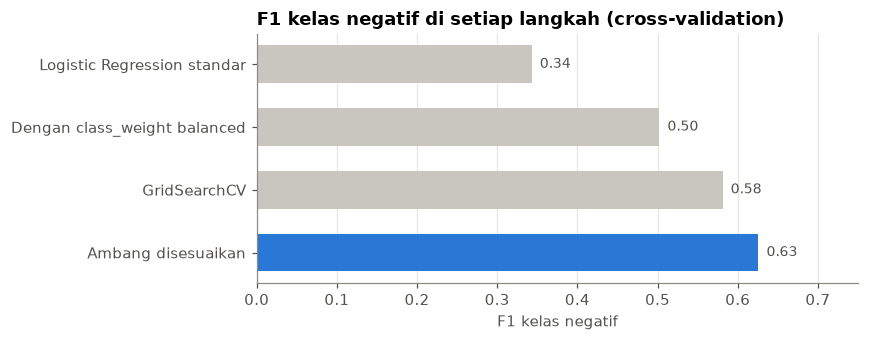

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.2))
urut = tabel["f1"]
warna = [ABU] * (len(urut) - 1) + [BIRU]
ax.barh(urut.index[::-1], urut.values[::-1], color=warna[::-1], height=0.6)
for y, v in enumerate(urut.values[::-1]):
    ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=9, color=TEKS)
ax.set_xlim(0, 0.75)
ax.set_title("F1 kelas negatif di setiap langkah (cross-validation)")
ax.set_xlabel("F1 kelas negatif")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Ambang yang ditemukan sekitar 0,23 untuk peluang negatif. Artinya, ulasan sudah ditebak negatif kalau model memberi peluang negatif sekitar 23% atau lebih. Dengan ambang ini, F1 cross-validation naik menjadi sekitar 0,63, dengan precision dan recall yang lebih seimbang.

Pemilihan ambang juga bisa disesuaikan dengan kebutuhan bisnis. Kalau tujuannya memastikan tidak ada keluhan yang terlewat, misalnya untuk tim layanan pelanggan, ambang bisa diturunkan lagi supaya recall lebih tinggi, dengan konsekuensi lebih banyak alarm palsu.

## 7. Evaluasi akhir di data uji

Semua keputusan (model, `C`, `class_weight`, dan ambang) sudah dibuat hanya dengan data latih. Sekarang model dinilai sekali di data uji.

Data uji tidak boleh dipakai untuk memilih model. Kalau beberapa model dicoba lalu dipilih yang skornya paling bagus di data uji, skor itu tidak lagi jujur, karena pilihannya sudah disesuaikan dengan data uji.

In [13]:
prediksi_uji = model_akhir.predict(X_uji)
print(classification_report(y_uji, prediksi_uji, digits=3))

              precision    recall  f1-score   support

     negatif      0.653     0.592     0.621       184
     positif      0.990     0.992     0.991      7533

    accuracy                          0.983      7717
   macro avg      0.821     0.792     0.806      7717
weighted avg      0.982     0.983     0.982      7717



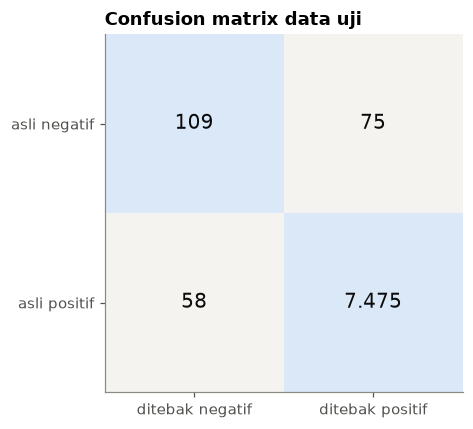

In [14]:
label_urut = ["negatif", "positif"]
matriks = confusion_matrix(y_uji, prediksi_uji, labels=label_urut)

fig, ax = plt.subplots(figsize=(4.8, 4))
ax.imshow([[1, 0], [0, 1]], cmap=plt.matplotlib.colors.ListedColormap(["#f4f3ef", "#dbe8f8"]))
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matriks[i, j]:,}".replace(",", "."), ha="center", va="center", fontsize=13, color="#0b0b0b")
ax.set_xticks([0, 1], labels=[f"ditebak {l}" for l in label_urut])
ax.set_yticks([0, 1], labels=[f"asli {l}" for l in label_urut])
ax.grid(False)
ax.set_title("Confusion matrix data uji")
plt.tight_layout()
plt.show()

Cara membaca confusion matrix:

- Kiri atas: ulasan negatif yang berhasil ditemukan.
- Kanan atas: ulasan negatif yang terlewat (ditebak positif).
- Kiri bawah: ulasan positif yang salah ditandai negatif (alarm palsu).
- Kanan bawah: ulasan positif yang ditebak benar.

Di data uji, F1 kelas negatif sekitar 0,62, sangat dekat dengan skor cross-validation (0,63). Kedekatan ini tanda yang baik: model tidak sekadar menghafal data latih, dan skor cross-validation bisa dipercaya sebagai perkiraan kemampuan model.

Dari 184 ulasan negatif di data uji, model menemukan sekitar 59%. Dari semua ulasan yang ditandai negatif, sekitar 65% benar-benar negatif. Akurasi keseluruhan 98,3%, sedikit di atas model patokan (97,6%), tetapi perbedaan yang penting ada di kelas negatif: dari 0 menjadi lebih dari separuh keluhan yang berhasil ditemukan.

## 8. Kata yang paling berpengaruh

Bobot Logistic Regression bisa dibaca langsung. Karena urutan kelasnya `["negatif", "positif"]`, bobot positif mendorong tebakan ke arah "positif", dan bobot negatif mendorong ke arah "negatif".

In [15]:
pipeline_terlatih = model_akhir.estimator_
kosakata = pipeline_terlatih.named_steps["tfidf"].get_feature_names_out()
bobot = pd.Series(pipeline_terlatih.named_steps["model"].coef_[0], index=kosakata)

print("Jumlah kata dan pasangan kata di kosakata:", len(kosakata))
paling_negatif = bobot.nsmallest(15)
paling_positif = bobot.nlargest(15)

Jumlah kata dan pasangan kata di kosakata: 19622


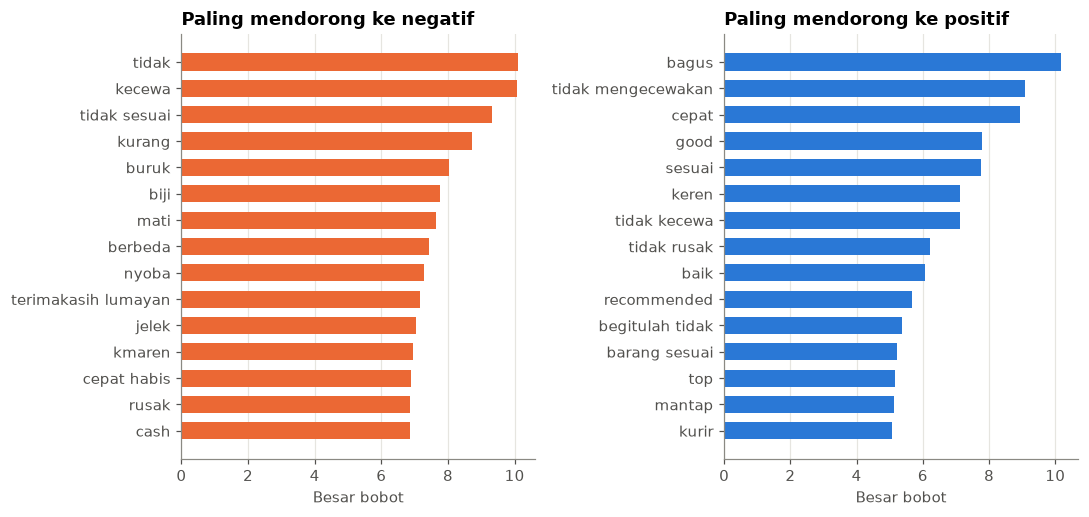

In [16]:
fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(10, 4.8))
for ax, data, warna, judul in [
    (kiri, paling_negatif.abs(), ORANYE, "Paling mendorong ke negatif"),
    (kanan, paling_positif, BIRU, "Paling mendorong ke positif"),
]:
    data = data.sort_values()
    ax.barh(data.index, data.values, color=warna, height=0.65)
    ax.set_title(judul)
    ax.set_xlabel("Besar bobot")
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Sebagian besar kata yang dipelajari model masuk akal:

- Ke arah negatif: "tidak", "kecewa", "tidak sesuai", "kurang", "buruk", "mati", "jelek", dan "rusak".
- Ke arah positif: "bagus", "cepat", "good", "sesuai", "keren", dan "mantap".

Yang paling menarik adalah pasangan kata "tidak mengecewakan", "tidak kecewa", dan "tidak rusak", yang justru mendorong kuat ke arah positif. Kata "tidak" sendiri mendorong ke negatif, tetapi berkat bigram, model belajar bahwa "tidak" yang diikuti kata negatif membalik maknanya. Ini bukti `ngram_range=(1, 2)` memang berguna.

Ada juga beberapa kata yang kurang masuk akal, seperti "biji", "cash", dan "kmaren" yang ke arah negatif, atau "kurir" yang ke arah positif. Kata-kata ini kemungkinan kebetulan muncul di beberapa ulasan tertentu saja, dan model dengan `C` besar cenderung ikut menghafal kebetulan seperti ini. Ini salah satu bentuk overfitting kecil yang biasa terjadi.

## 9. Analisis kesalahan

Melihat contoh yang salah ditebak membantu memahami batas kemampuan model.

In [17]:
hasil_uji = pd.DataFrame({"teks": df.loc[X_uji.index, "teks"], "asli": y_uji, "tebakan": prediksi_uji})

print("Negatif yang terlewat (ditebak positif):")
with pd.option_context("display.max_colwidth", 110):
    display(hasil_uji[(hasil_uji["asli"] == "negatif") & (hasil_uji["tebakan"] == "positif")].sample(8, random_state=1))

Negatif yang terlewat (ditebak positif):


,teks,asli,tebakan
24290,"barang sesuai,, tapi pengiriman masalah mustinya gran cepet jadi nunda 3 hari",negatif,positif
14208,Lumayan dah buat koleksi Anak anak,negatif,positif
15740,"waduhhh bro kurang teliti dalam QC , tp utk harga segitu ok lah ... ada yg bopeng dibagian lingkaran jam d...",negatif,positif
11318,"Produk memang sesuai deskripsi,tp pengiriman 26 hr bru sampai stelah bbrp kli teguran...ekspektasi bs unt ...",negatif,positif
19670,lumaaayaaaaannnn.......,negatif,positif
31107,"Untuk produk ini saya kasi 2 bintang saja krna celananya tdk sesuai yg di foto, celanax kependekan tdk di ...",negatif,positif
4301,Kagak pas di motor ninja 250 fi.. \nSama kagak pas di polygon stratos..,negatif,positif
2525,Lebih teliti lg ya gan kalau ngasih informasi,negatif,positif


In [18]:
print("Positif yang ditandai negatif (alarm palsu):")
with pd.option_context("display.max_colwidth", 110):
    display(hasil_uji[(hasil_uji["asli"] == "positif") & (hasil_uji["tebakan"] == "negatif")].sample(8, random_state=1))

Positif yang ditandai negatif (alarm palsu):


,teks,asli,tebakan
26821,Barang tidak sesuai di foto tidak ada tulisannya asus. respon cepat,positif,negatif
23071,digambar warna biru dikirim warna putih,positif,negatif
36574,"Lumayan. Beli tapi beda model. yg 1 ada logonya, 1 lg enggak. thanks",positif,negatif
4978,Brg ny uda rusak gan. Ada garansinya?,positif,negatif
17859,"ya begitu deh , setelah barang nyampe penjual lepas tangan chat udh ga dibalas",positif,negatif
38442,gaaan..udah ditulis dropship malah ditulis nama pengirimnya pusat dermawand. ampuuun deh >.<,positif,negatif
10279,Gapernah kecewa beli disini hehe,positif,negatif
17170,Ulasan tidak boleh kosong~,positif,negatif


Pola kesalahan yang umum:

- Ulasan campuran yang memuat pujian dan keluhan sekaligus, misalnya "barang sesuai, tapi pengiriman masalah" atau "produk memang sesuai deskripsi, tapi pengiriman 26 hari". Kata pujian di awal kalimat membuat model condong ke positif.
- Keluhan yang disampaikan dengan halus, tanpa kata negatif yang jelas, misalnya "lebih teliti lagi ya gan" atau "lumayan". Pembeli memberi 1 atau 2 bintang, tetapi kata-katanya tidak terdengar negatif.
- Label noise dari arah sebaliknya. Beberapa ulasan dengan bintang 4 atau 5 isinya jelas keluhan, misalnya "barang tidak sesuai di foto" atau "barang sudah rusak gan, ada garansinya?". Model menebak negatif, dan tebakan itu sebenarnya lebih masuk akal daripada labelnya.
- Singkatan yang tidak ada di kamus normalisasi, misalnya "gapernah kecewa" (maksudnya "tidak pernah kecewa"). Karena "gapernah" tidak dikenali, model hanya melihat kata "kecewa".

In [19]:
# Mencoba kalimat baru. Teksnya ditulis dalam bentuk yang sudah bersih,
# karena model menerima hasil fungsi bersihkan_teks dari notebook 05.
kalimat = pd.Series([
    "barang bagus pengiriman cepat",
    "barang tidak sesuai kecewa",
    "barang bagus tapi pengiriman lama",
    "tidak jelek kok",
    "ukurannya kekecilan",
])
peluang_negatif = model_akhir.predict_proba(kalimat)[:, list(model_akhir.classes_).index("negatif")]
pd.DataFrame({"kalimat": kalimat, "tebakan": model_akhir.predict(kalimat), "peluang_negatif": peluang_negatif.round(3)})

,kalimat,tebakan,peluang_negatif
0,barang bagus pengiriman cepat,positif,0.000
1,barang tidak sesuai kecewa,negatif,1.000
2,barang bagus tapi pengiriman lama,positif,0.010
3,tidak jelek kok,negatif,0.968
4,ukurannya kekecilan,positif,0.032


Contoh "tidak jelek kok" menunjukkan keterbatasan model berbasis kata. Pasangan "tidak jelek" terlalu jarang muncul di data latih, sehingga model hanya melihat kata "tidak" dan "jelek" yang keduanya bobotnya negatif. Berbeda dengan "tidak kecewa" yang cukup sering muncul dan sudah dipelajari sebagai positif. Contoh "ukurannya kekecilan" juga lolos sebagai positif karena tidak ada kata negatif yang jelas. Model yang memahami susunan kalimat, seperti IndoBERT, bisa menangani kasus ini lebih baik, tetapi jauh lebih berat untuk dilatih dan dijalankan.

## 10. Simpan model

Model disimpan dengan `joblib` ke folder `models/`. Yang disimpan adalah seluruh rangkaian: TF-IDF, Logistic Regression, dan ambang keputusannya. Jadi di dashboard cukup memuat satu file ini, lalu memanggil `predict`.

Hal penting saat memakai model ini: teks yang diberikan ke model harus dibersihkan dulu dengan fungsi `bersihkan_teks` yang sama persis seperti di notebook 05. Kalau pembersihannya berbeda, misalnya "gk" tidak diubah menjadi "tidak", model akan menerima kata yang tidak pernah dilihatnya saat belajar.

Ringkasan skor juga disimpan dalam file JSON, supaya dashboard bisa menampilkan seberapa akurat model ini.

In [20]:
folder_model = Path("../models")
folder_model.mkdir(exist_ok=True)

joblib.dump(model_akhir, folder_model / "sentimen.joblib")

laporan = classification_report(y_uji, prediksi_uji, output_dict=True)
metrik = {
    "model": "TF-IDF (1-2 gram) + Logistic Regression",
    "C": C_terbaik,
    "class_weight": cw_terbaik,
    "ambang_peluang_negatif": round(float(model_akhir.best_threshold_), 4),
    "data_latih": int(len(X_latih)),
    "data_uji": int(len(X_uji)),
    "uji_precision_negatif": round(laporan["negatif"]["precision"], 4),
    "uji_recall_negatif": round(laporan["negatif"]["recall"], 4),
    "uji_f1_negatif": round(laporan["negatif"]["f1-score"], 4),
    "uji_akurasi": round(laporan["accuracy"], 4),
}
(folder_model / "sentimen_metrik.json").write_text(json.dumps(metrik, indent=2))
metrik

{'model': 'TF-IDF (1-2 gram) + Logistic Regression',
 'C': 30,
 'class_weight': None,
 'ambang_peluang_negatif': 0.2323,
 'data_latih': 30868,
 'data_uji': 7717,
 'uji_precision_negatif': 0.6527,
 'uji_recall_negatif': 0.5924,
 'uji_f1_negatif': 0.6211,
 'uji_akurasi': 0.9828}

In [21]:
# Pastikan model yang tersimpan bisa dimuat ulang dan memberi hasil yang sama
model_muat = joblib.load(folder_model / "sentimen.joblib")
assert (model_muat.predict(X_uji) == prediksi_uji).all()
model_muat.predict(pd.Series(["barang tidak sesuai kecewa"]))

array(['negatif'], dtype=object)

## Ringkasan

| Langkah | F1 negatif (cross-validation) |
|---|---|
| Model patokan (selalu positif) | 0 |
| Logistic Regression standar | sekitar 0,34 |
| Dengan class_weight balanced | sekitar 0,50 |
| GridSearchCV (C=30) | sekitar 0,58 |
| Ambang disesuaikan | sekitar 0,63 |

Di data uji, model akhir mendapat F1 kelas negatif sekitar 0,62, dengan precision sekitar 65% dan recall sekitar 59%.

Keterbatasan:

- Label berasal dari rating, dan sebagian rating tidak cocok dengan isi ulasan. Skor model ikut terpengaruh oleh label yang keliru ini.
- Model berbasis kata tidak memahami susunan kalimat, sehingga kalimat seperti "tidak jelek" bisa salah ditebak.
- Ulasan negatif di data latih didominasi kategori handphone, dan semua ulasan berasal dari tahun 2019 dan 158 toko. Model mungkin kurang akurat untuk kategori atau gaya bahasa yang berbeda.